In [ ]:
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# 2. UPLOAD DATASET

from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
print(list(uploaded.keys()))

Saving Visadataset.csv to Visadataset (1).csv
Uploaded files:
['Visadataset (1).csv']


In [ ]:
# 3. LOAD DATASET

df = pd.read_csv("Visadataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (25480, 12)


In [ ]:
# 4. BASIC DATA INSPECTION

display(df.head())

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Dataset shape:
(25480, 12)

Column names:
['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'no_of_employees', 'yr_of_estab', 'region_of_employment', 'prevailing_wage', 'unit_of_wage', 'full_time_position', 'case_status']

Data types:
case_id                   object
continent                 object
education_of_employee     object
has_job_experience        object
requires_job_training     object
no_of_employees            int64
yr_of_estab                int64
region_of_employment      object
prevailing_wage          float64
unit_of_wage              object
full_time_position        object
case_status               object
dtype: object


In [ ]:
# 5. DATASET INFORMATION

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
# 6. NUMERICAL STATISTICS

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 7. CHECK MISSING VALUES

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2)
})

display(missing.sort_values("Missing_Count", ascending=False))

,Missing_Count,Missing_Percentage
case_id,0,0.0
continent,0,0.0
education_of_employee,0,0.0
has_job_experience,0,0.0
requires_job_training,0,0.0
no_of_employees,0,0.0
yr_of_estab,0,0.0
region_of_employment,0,0.0
prevailing_wage,0,0.0
unit_of_wage,0,0.0


In [ ]:
# 8. CHECK DUPLICATES

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
# 9. TARGET DISTRIBUTION

print(df["case_status"].value_counts())

print("\nTarget percentage:")
print(
    df["case_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

Target percentage:
case_status
Certified    66.79
Denied       33.21
Name: proportion, dtype: float64


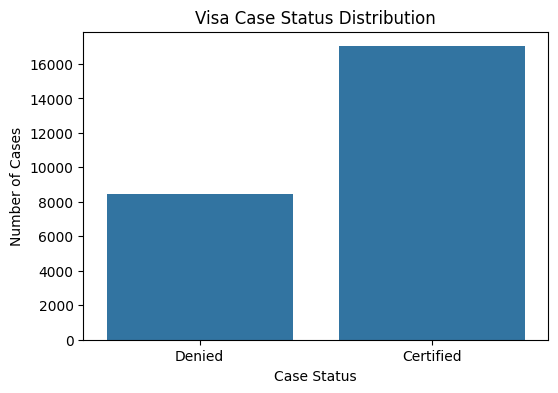

In [ ]:
# 9B. TARGET VISUALIZATION


plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="case_status"
)

plt.title("Visa Case Status Distribution")
plt.xlabel("Case Status")
plt.ylabel("Number of Cases")

plt.show()

In [ ]:
# 10. UNIQUE VALUES PER COLUMN


for column in df.columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())

    if df[column].nunique() <= 15:
        print(df[column].unique())


case_id
Unique values: 25480

continent
Unique values: 6
['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']

education_of_employee
Unique values: 4
['High School' "Master's" "Bachelor's" 'Doctorate']

has_job_experience
Unique values: 2
['N' 'Y']

requires_job_training
Unique values: 2
['N' 'Y']

no_of_employees
Unique values: 7105

yr_of_estab
Unique values: 199

region_of_employment
Unique values: 5
['West' 'Northeast' 'South' 'Midwest' 'Island']

prevailing_wage
Unique values: 25454

unit_of_wage
Unique values: 4
['Hour' 'Year' 'Week' 'Month']

full_time_position
Unique values: 2
['Y' 'N']

case_status
Unique values: 2
['Denied' 'Certified']


In [ ]:
#11.Check the index/case ID
print("Unique case IDs:", df["case_id"].nunique())
print("Total rows:", len(df))

Unique case IDs: 25480
Total rows: 25480


In [ ]:
# 12. CATEGORICAL FEATURE DISTRIBUTIONS


categorical_columns = [
    "continent",
    "education_of_employee",
    "has_job_experience",
    "requires_job_training",
    "region_of_employment",
    "unit_of_wage",
    "full_time_position"
]

for column in categorical_columns:
    print(f"\n===== {column} =====")
    print(df[column].value_counts(dropna=False))


===== continent =====
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

===== education_of_employee =====
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

===== has_job_experience =====
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

===== requires_job_training =====
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

===== region_of_employment =====
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64

===== unit_of_wage =====
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64

===== full_time_position =====
full_time_position
Y    22773
N     2707
Name: count, dtype: int64


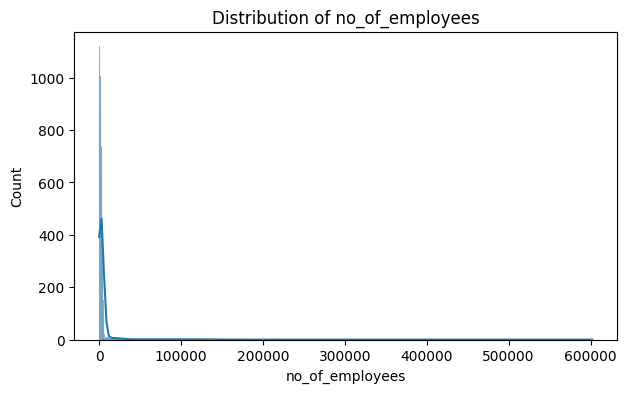

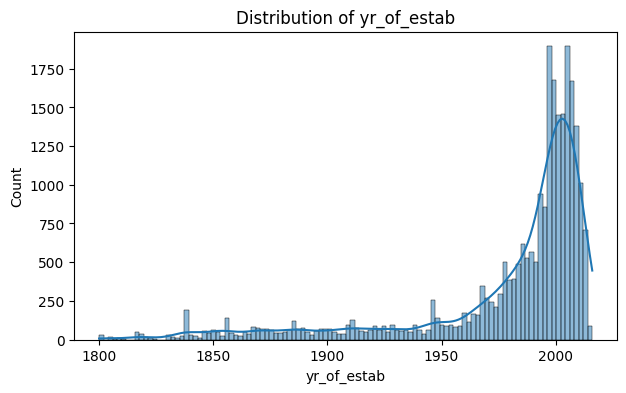

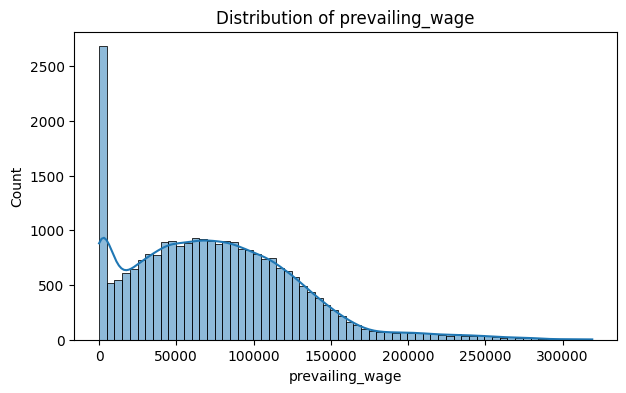

In [ ]:
# 13. NUMERICAL FEATURE DISTRIBUTIONS

numerical_columns = [
    "no_of_employees",
    "yr_of_estab",
    "prevailing_wage"
]

for column in numerical_columns:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.show()

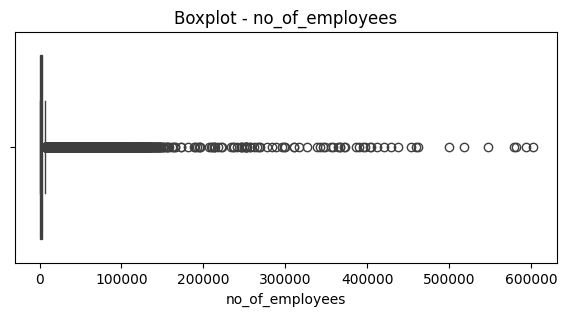

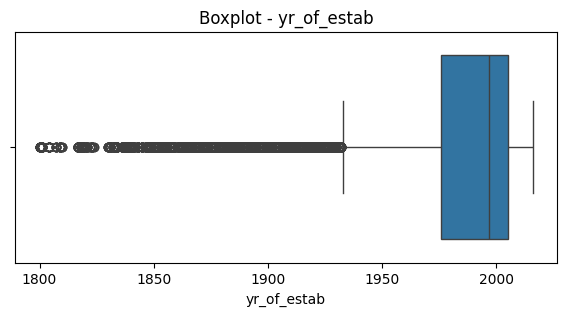

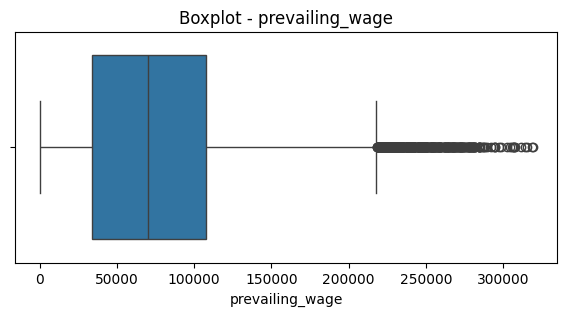

In [ ]:
# 14. OUTLIER INSPECTION

for column in numerical_columns:
    plt.figure(figsize=(7, 3))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Boxplot - {column}")
    plt.show()

In [ ]:
# 15. WAGE UNIT ANALYSIS


display(
    df.groupby("unit_of_wage")["prevailing_wage"]
    .agg(["count", "min", "mean", "median", "max"])
)

,count,min,mean,median,max
unit_of_wage,,,,,
Hour,2157,2.1367,414.570513,372.6523,999.9195
Month,89,1599.2800,87592.864045,81826.0100,264362.9500
Week,272,2183.2300,85606.820515,85075.8200,280175.9500
Year,22962,100.0000,81228.077133,76174.5000,319210.2700


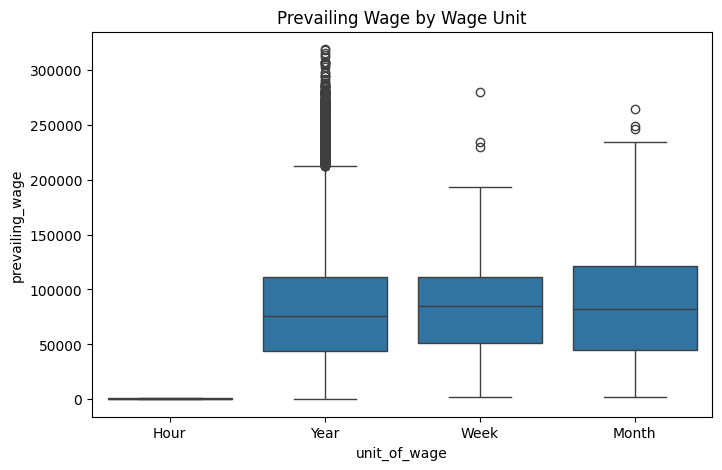

In [ ]:
# Compare wage distributions by unit
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="unit_of_wage",
    y="prevailing_wage"
)

plt.title("Prevailing Wage by Wage Unit")
plt.show()

In [ ]:
# 16. CREATE ANNUALIZED WAGE

df["annual_wage"] = np.where(
    df["unit_of_wage"] == "Hour",
    df["prevailing_wage"] * 2080,
    df["prevailing_wage"]
)

display(
    df[
        [
            "prevailing_wage",
            "unit_of_wage",
            "annual_wage"
        ]
    ].head(10)
)

,prevailing_wage,unit_of_wage,annual_wage
0,592.2029,Hour,1231782.032
1,83425.6500,Year,83425.650
2,122996.8600,Year,122996.860
3,83434.0300,Year,83434.030
4,149907.3900,Year,149907.390
5,78252.1400,Year,78252.140
6,53635.3900,Year,53635.390
7,418.2298,Hour,869917.984
8,74362.1900,Year,74362.190
9,67514.7600,Year,67514.760


In [ ]:
# 17. ESTABLISHMENT YEAR INSPECTION


print("Minimum establishment year:",
      df["yr_of_estab"].min())

print("Maximum establishment year:",
      df["yr_of_estab"].max())

display(
    df["yr_of_estab"]
    .describe()
)

Minimum establishment year: 1800
Maximum establishment year: 2016


,yr_of_estab
count,25480.000000
mean,1979.409929
std,42.366929
min,1800.000000
25%,1976.000000
50%,1997.000000
75%,2005.000000
max,2016.000000


In [ ]:
# Inspect unusually old establishments
display(
    df[df["yr_of_estab"] < 1900]
    [["case_id", "yr_of_estab", "case_status"]]
    .head(20)
)

,case_id,yr_of_estab,case_status
3,EZYV04,1897,Denied
23,EZYV24,1884,Certified
31,EZYV32,1880,Certified
67,EZYV68,1847,Certified
73,EZYV74,1890,Certified
76,EZYV77,1838,Certified
111,EZYV112,1864,Certified
132,EZYV133,1818,Certified
136,EZYV137,1839,Certified
142,EZYV143,1855,Certified


In [ ]:
# 18. CREATE COMPANY AGE FEATURE


REFERENCE_YEAR = 2016

df["company_age"] = (
    REFERENCE_YEAR - df["yr_of_estab"]
)

display(
    df[
        [
            "yr_of_estab",
            "company_age"
        ]
    ].head()
)

,yr_of_estab,company_age
0,2007,9
1,2002,14
2,2008,8
3,1897,119
4,2005,11


In [ ]:
# 19. EDUCATION VS TARGET

education_status = pd.crosstab(
    df["education_of_employee"],
    df["case_status"],
    normalize="index"
) * 100

display(education_status.round(2))

case_status,Certified,Denied
education_of_employee,,
Bachelor's,62.21,37.79
Doctorate,87.23,12.77
High School,34.04,65.96
Master's,78.63,21.37


In [ ]:
# 20. EXPERIENCE VS TARGET

experience_status = pd.crosstab(
    df["has_job_experience"],
    df["case_status"],
    normalize="index"
) * 100

display(experience_status.round(2))

case_status,Certified,Denied
has_job_experience,,
N,56.13,43.87
Y,74.48,25.52


In [ ]:
# 21. TRAINING VS TARGET

training_status = pd.crosstab(
    df["requires_job_training"],
    df["case_status"],
    normalize="index"
) * 100

display(training_status.round(2))

case_status,Certified,Denied
requires_job_training,,
N,66.65,33.35
Y,67.88,32.12


In [ ]:
# 22. REGION VS TARGET


region_status = pd.crosstab(
    df["region_of_employment"],
    df["case_status"],
    normalize="index"
) * 100

display(region_status.round(2))

case_status,Certified,Denied
region_of_employment,,
Island,60.27,39.73
Midwest,75.53,24.47
Northeast,62.90,37.10
South,70.02,29.98
West,62.25,37.75


In [ ]:
# 23. SIMPLE NUMERICAL CORRELATION


corr_df = df.copy()

binary_mapping = {
    "Y": 1,
    "N": 0
}

for column in [
    "has_job_experience",
    "requires_job_training",
    "full_time_position"
]:
    corr_df[column] = corr_df[column].map(binary_mapping)

corr_df["target"] = (
    corr_df["case_status"] == "Certified"
).astype(int)

display(
    corr_df[
        [
            "no_of_employees",
            "yr_of_estab",
            "prevailing_wage",
            "annual_wage",
            "company_age",
            "has_job_experience",
            "requires_job_training",
            "full_time_position",
            "target"
        ]
    ].corr()["target"]
    .sort_values(ascending=False)
)

,target
target,1.000000
has_job_experience,0.192162
prevailing_wage,0.076198
no_of_employees,0.008677
yr_of_estab,0.008597
requires_job_training,0.008423
company_age,-0.008597
full_time_position,-0.012711
annual_wage,-0.159964


In [ ]:
# 24. REMOVE IDENTIFIER COLUMNS

df_model = df.copy()

df_model = df_model.drop(
    columns=["case_id"]
)

print("New shape:", df_model.shape)

New shape: (25480, 13)


In [ ]:
# 25. REMOVE MISSING TARGET ROWS

before = len(df_model)

df_model = df_model.dropna(
    subset=["case_status"]
)

after = len(df_model)

print("Rows before:", before)
print("Rows after :", after)
print("Removed    :", before - after)

Rows before: 25480
Rows after : 25480
Removed    : 0


In [ ]:
# 26. CLEAN CATEGORICAL VALUES


categorical_columns = [
    "continent",
    "education_of_employee",
    "has_job_experience",
    "requires_job_training",
    "region_of_employment",
    "unit_of_wage",
    "full_time_position",
    "case_status"
]

for column in categorical_columns:
    df_model[column] = (
        df_model[column]
        .astype("string")
        .str.strip()
    )

print("Categorical values cleaned.")

Categorical values cleaned.


In [ ]:
# 27. FINAL DATA QUALITY CHECK


print("Shape:", df_model.shape)

print("\nMissing values:")
print(df_model.isnull().sum())

print("\nDuplicates:")
print(df_model.duplicated().sum())

Shape: (25480, 13)

Missing values:
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
annual_wage              0
company_age              0
dtype: int64

Duplicates:
0


In [ ]:
# 28. DEFINE FEATURES AND TARGET


X = df_model.drop(
    columns=["case_status"]
)

y = (
    df_model["case_status"]
    .map({
        "Denied": 0,
        "Certified": 1
    })
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (25480, 12)
y shape: (25480,)

Target distribution:
case_status
1    17018
0     8462
Name: count, dtype: int64


In [ ]:
# 29. TRAIN / TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (20384, 12)
Testing : (5096, 12)


In [ ]:
# 30. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES


categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position']

Numerical features:
['no_of_employees', 'yr_of_estab', 'prevailing_wage', 'annual_wage', 'company_age']


In [ ]:
# 31. INSTALL / VERIFY XGBOOST


!pip install -q xgboost

In [ ]:
# 32. IMPORT XGBOOST


import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.3.0


In [ ]:
# 33. PREPARE FEATURES AND TARGET

X = df_model.drop(columns=["case_status"])

y = df_model["case_status"].map({
    "Denied": 0,
    "Certified": 1
})

print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features: (25480, 12)
Target: (25480,)

Target distribution:
case_status
1    17018
0     8462
Name: count, dtype: int64


In [ ]:
# 34. TRAIN / TEST SPLIT


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (20384, 12)
X_test : (5096, 12)


In [ ]:
# 35. ONE-HOT ENCODE CATEGORICAL FEATURES


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "numerical",
            SimpleImputer(strategy="median"),
            numerical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (20384, 30)
Processed testing shape : (5096, 30)


In [ ]:
# 36. TRAIN XGBOOST

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_processed,
    y_train
)

print("✅ XGBoost trained successfully.")

✅ XGBoost trained successfully.


In [ ]:
# 37. EVALUATE XGBOOST


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = model.predict(X_test_processed)
y_prob = model.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7396
Precision: 0.7724
Recall   : 0.8652
F1 Score : 0.8161
ROC-AUC  : 0.7664

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.49      0.55      1692
           1       0.77      0.87      0.82      3404

    accuracy                           0.74      5096
   macro avg       0.71      0.68      0.69      5096
weighted avg       0.73      0.74      0.73      5096



In [ ]:
# 38. XGBOOST TUNING

from xgboost import XGBClassifier

tuned_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

tuned_xgb.fit(
    X_train_processed,
    y_train
)

tuned_pred = tuned_xgb.predict(X_test_processed)
tuned_prob = tuned_xgb.predict_proba(X_test_processed)[:, 1]

print("Tuned XGBoost Results")
print("=" * 40)

print("Accuracy :", round(accuracy_score(y_test, tuned_pred), 4))
print("Precision:", round(precision_score(y_test, tuned_pred), 4))
print("Recall   :", round(recall_score(y_test, tuned_pred), 4))
print("F1 Score :", round(f1_score(y_test, tuned_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, tuned_prob), 4))

Tuned XGBoost Results
Accuracy : 0.7429
Precision: 0.7748
Recall   : 0.8672
F1 Score : 0.8184
ROC-AUC  : 0.7696


In [ ]:
# 40. SAVE FINAL XGBOOST MODEL PACKAGE


import joblib
import json

final_model_package = {
    "model": tuned_xgb,
    "preprocessor": preprocessor,
    "features": X.columns.tolist(),
    "target_mapping": {
        "Denied": 0,
        "Certified": 1
    },
    "metrics": {
        "accuracy": float(accuracy_score(y_test, tuned_pred)),
        "precision": float(precision_score(y_test, tuned_pred)),
        "recall": float(recall_score(y_test, tuned_pred)),
        "f1": float(f1_score(y_test, tuned_pred)),
        "roc_auc": float(roc_auc_score(y_test, tuned_prob))
    }
}

joblib.dump(
    final_model_package,
    "visa_xgboost_final.pkl"
)

print("✅ Final model saved as visa_xgboost_final.pkl")

✅ Final model saved as visa_xgboost_final.pkl
